# test-nelson18: TEA ET partitioning for CH-Oe2

Application of the Transpiration Estimation Algorithm (TEA; Nelson et al., 2018, *Biogeosciences*, 15, 2433–2447) to the
[CH-Oe2 (Oensingen crop)](http://sites.fluxdata.org/CH-Oe2/) eddy covariance site, following the steps of `TEA_tutorial.ipynb`.

Differences from `TEA_tutorial.ipynb` (the original files are **not** modified):

- The CH-Oe2 FLUXNET file has no `NETRAD` and `PPFD_OUT` columns, so `preprocess.build_dataset` (which requests every column in
  `BerkeleyConversion.json`) cannot read it. A local loader `build_dataset_oe2` below does the same thing but only reads the
  columns that exist; missing ones are filled with NaN (none of them are used by TEA).
- Short gaps in measured precipitation `P` are filled with the ERA-gapfilled `P_F`, because TEA's surface-wetness index (CSWI) needs a continuous precipitation record.
- Output files are prefixed with `CH-Oe2_` so no existing output is overwritten.

### settings
Change the site file, period, or number of processors here.

In [1]:
SITE      = "CH-Oe2"
DATA_FILE = r"testdata\EUF_CH-Oe2_FLUXNET_FLUXMET_HH_2004-2024_v1.3_r1.csv"
START, END = "2017", "2019"   # period to partition (years with good-quality LE/NEE data)
N_JOBS    = 4                  # processors used by the random forest
GPP_VAR   = "GPP_NT"           # or "GPP_DT" for daytime-partitioned GPP

### imports

In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import warnings
from datetime import datetime

import TEA # This is the actual TEA code

from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()
%matplotlib inline
import matplotlib.pyplot as pl

# reuse the variable maps from the repository's preprocess.py (imported read-only, the file is not changed)
from preprocess import BerkeleyConversion, Units, LongNames
import bigleaf # Used for converting units (e.g. LE to ET)

### loading the dataset

`build_dataset_oe2` mirrors `preprocess.build_dataset`, but tolerates columns that are absent from the file. It also keeps `P_F`
(gap-filled precipitation) so gaps in `P` can be filled.

In [3]:
def build_dataset_oe2(_file, extra_cols=('P_F',)):
    header = pd.read_csv(_file, nrows=0).columns
    wanted = ['TIMESTAMP_START', 'TIMESTAMP_END'] + list(BerkeleyConversion.keys()) + list(extra_cols)
    missing = [c for c in wanted if c not in header]
    if missing:
        print("columns not in file, filled with NaN:", missing)
    df = pd.read_csv(_file, sep=',', keep_default_na=False,
                     usecols=[c for c in wanted if c in header])
    df['TIMESTAMP_START'] = pd.to_datetime(df['TIMESTAMP_START'], format="%Y%m%d%H%M")
    df['TIMESTAMP_END']   = pd.to_datetime(df['TIMESTAMP_END'],   format="%Y%m%d%H%M")
    # timestamp = middle of the averaging period (as in preprocess.build_dataset)
    df['time'] = df['TIMESTAMP_START'] + (df['TIMESTAMP_END'] - df['TIMESTAMP_START']) / 2
    ds = df.set_index('time').to_xarray()
    for var in BerkeleyConversion.keys():
        if var not in ds.variables:
            ds[var] = ds.TA_F_MDS * np.nan
    keep = list(BerkeleyConversion.keys()) + [c for c in extra_cols if c in ds.variables]
    ds = ds[keep].rename(BerkeleyConversion)

    ds.attrs['agg_code'] = 'HR' if np.isnan(ds.H.where(ds.H != -9999).values[::2]).all() else 'HH'
    for _var in Units.keys():
        if _var not in ds.variables:
            ds[_var] = ds['SW_IN_POT'] * np.nan
        ds[_var] = ds[_var].assign_attrs(units=Units[_var], long_name=LongNames[_var])
    ds = ds.where(ds != -9999)
    ds.attrs['site'] = SITE
    ds.attrs['build_timestamp'] = datetime.now().strftime("%Y-%m-%d %H:%M")
    return ds

iniec = build_dataset_oe2(DATA_FILE)
ec = iniec.sel(time=slice(START, END))
ec

columns not in file, filled with NaN: ['NETRAD', 'PPFD_OUT']


<xarray.Dataset> Size: 21MB
Dimensions:        (time: 52560)
Coordinates:
  * time           (time) datetime64[ns] 420kB 2017-01-01T00:15:00 ... 2019-1...
Data variables: (12/50)
    CO2            (time) float64 420kB 457.4 458.8 456.9 ... 456.0 455.6 454.1
    CO2_QC         (time) float64 420kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    GPP_DT         (time) float64 420kB 0.0 0.0 0.0 0.0 ... 0.002829 0.0 0.0166
    GPP_NT         (time) float64 420kB -0.5057 0.3204 0.8898 ... 0.1968 0.5913
    G              (time) float64 420kB nan nan nan nan ... -8.704 -8.721 -8.662
    G_QC           (time) float64 420kB nan nan nan nan nan ... 0.0 0.0 0.0 0.0
    ...             ...
    TS_2_QC        (time) float64 420kB 1.0 2.0 2.0 2.0 2.0 ... 3.0 3.0 3.0 3.0
    USTAR          (time) float64 420kB 0.1364 0.1235 0.1419 ... 0.2566 0.192
    VPD            (time) float64 420kB 0.095 0.064 0.061 0.062 ... 0.0 0.0 0.0
    VPD_QC         (time) float64 420kB 1.0 2.0 2.0 2.0 2.0 ... 0.0 0.0 0.0 0.0
    WS             (time) float64 420kB 2.067 2.208 1.941 ... 1.987 2.9 2.283
    P_F            (time) float64 420kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Attributes:
    agg_code:         HH
    site:             CH-Oe2
    build_timestamp:  2026-09-25 16:00

### fill precipitation gaps
`P` is the measured precipitation; `P_F` is the same record gap-filled with ERA5. Only the missing steps are replaced.

In [4]:
nP = int(ec.P.isnull().sum())
ec['P'] = ec.P.fillna(ec.P_F).assign_attrs(ec.P.attrs)
print(f"filled {nP} missing P steps with P_F; remaining NaN: {int(ec.P.isnull().sum())}")

filled 854 missing P steps with P_F; remaining NaN: 0


### check for an hourly file

In [5]:
if ec.agg_code == 'HH':
    nStepsPerDay = 48
else:
    nStepsPerDay = 24
print(ec.agg_code, nStepsPerDay)

HH 48


### unit conversions
LE → ET (mm per timestep) and VPD → relative humidity, using bigleaf.py.

In [6]:
ec['ET'] = (bigleaf.LE_to_ET(ec.LE, ec.TA)*60*60*(24/nStepsPerDay))
ec['ET'] = ec['ET'].assign_attrs(long_name = 'evapotranspiration',
                                 units     = 'mm per timestep')
ec['RH'] = bigleaf.VPD_to_RH(ec.VPD/10, ec.TA)
ec['RH'] = ec['RH'].assign_attrs(long_name = 'relative humidity',
                                 units     = '-')

### initial checks
Daily ET sums (a day with any missing step is NaN).

Text(0.5, 1.0, 'CH-Oe2 daily ET')

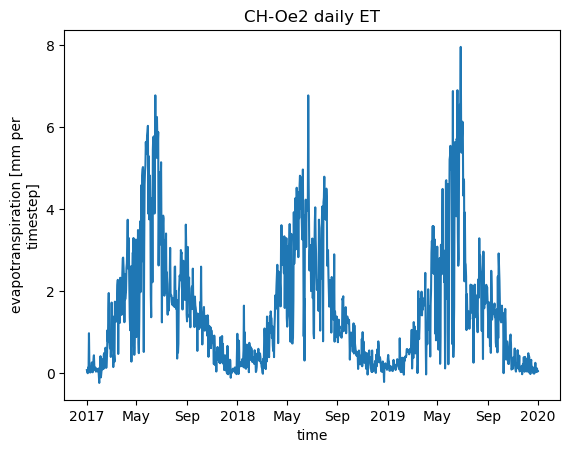

In [7]:
ec['ET'].resample(time='D').sum(skipna=False).plot()
pl.title(f"{SITE} daily ET")

### preprocess the data to run TEA

`qualityFlag` marks good-quality steps: measured, not gap-filled (QC=0), LE and NEE.

In [8]:
ET     = ec.ET.values
GPP    = ec[GPP_VAR].values
RH     = ec.RH.values
Rg     = ec.SW_IN.values
Rg_pot = ec.SW_IN_POT.values
Tair   = ec.TA.values
VPD    = ec.VPD.values
precip = ec.P.values
u      = ec.WS.values

qualityFlag = (ec.NEE_QC==0) & (ec.LE_QC==0)
qualityFlag = qualityFlag & np.isfinite(ec["ET"]) & np.isfinite(ec[GPP_VAR])
print("good-quality steps:", int(qualityFlag.sum()), "of", qualityFlag.size)

OtherVars = {'qualityFlag': qualityFlag.values}

ds = TEA.build_dataset(ec.time.values, ET, GPP, RH, Rg, Rg_pot, Tair, VPD, precip, u, OtherVars=OtherVars)

with warnings.catch_warnings():
    warnings.filterwarnings('ignore', r'invalid value encountered in (less|less-equal|greater|true_divide)')
    ds = TEA.preprocess(ds, nStepsPerDay=nStepsPerDay)

good-quality steps: 24076 of 52560


Conservative surface wetness index (CSWI) and the -0.5 mm threshold TEA uses to select dry periods.

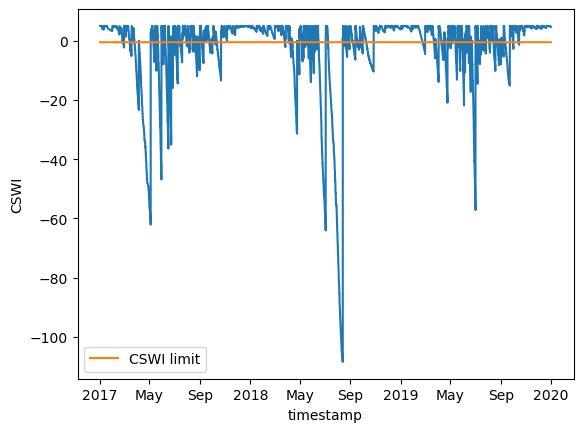

In [9]:
ds.CSWI.plot()
(ds.CSWI*0-0.5).plot(label='CSWI limit')
pl.legend()

### running the partitioning

- **CSWIlims** – CSWI limit (-0.5 is typical).
- **percs** – prediction percentiles to output; the 75th is the one used in Nelson et al. (2018).

In [10]:
%%time

CSWIlims = [-0.5]
percs    = [50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]

ds = TEA.partition(ds,
       percs    = np.array(percs),
       CSWIlims = np.array(CSWIlims),
       RandomForestRegressor_kwargs = {'n_jobs': N_JOBS}
       )

ds = ds.sel(CSWIlims=CSWIlims[0]) # only one CSWI limit, drop that dimension

CPU times: total: 28.6 s
Wall time: 14.9 s


### check the partitioning
If TEA_T is all NaN, list which covariates are missing.

In [11]:
if np.all(np.isnan(ds.TEA_T)):
    checkvars = ['Rg','Tair','RH','u','Rg_pot_daily','Rgpotgrad','year','GPPgrad','DWCI','C_Rg_ET','CSWI','precip']
    missingVars = [var for var in checkvars if np.all(~np.isfinite(ds[var].values))]
    if len(missingVars) > 0:
        print(f'TEA failed to run on {SITE}, {missingVars} are missing in EC file')
    else:
        print(f'TEA failed to run on {SITE}, unknown error')
else:
    print("Partitioning seems OK.")
    print("random forest OOB score:", float(ds.oob_scores.mean()))

Partitioning seems OK.
random forest OOB score: 0.34206800603769527


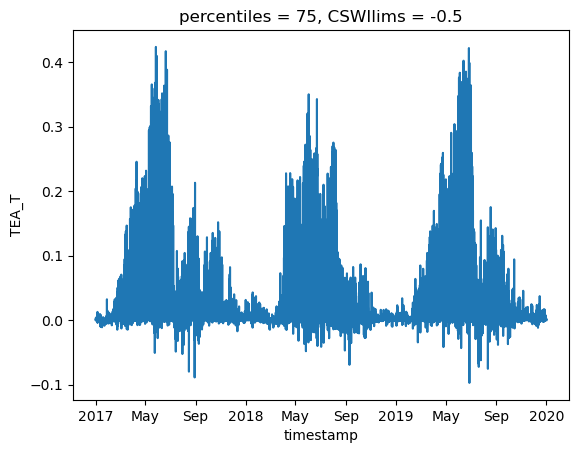

In [12]:
ds.TEA_T.sel(percentiles=75).plot()

Monthly sums of ET and TEA_T (75th percentile).

C:\Users\ziyguo\AppData\Local\miniconda3\envs\ecosystem-transpiration\lib\site-packages\xarray\groupers.py:513: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
C:\Users\ziyguo\AppData\Local\miniconda3\envs\ecosystem-transpiration\lib\site-packages\xarray\groupers.py:513: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


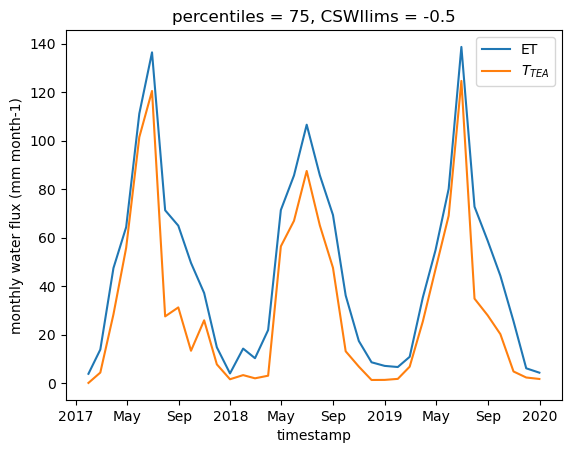

In [13]:
ds.ET.resample(timestamp='M').sum(skipna=False).plot(label='ET')
ds.TEA_T.sel(percentiles=75).resample(timestamp='M').sum(skipna=False).plot(label=r'$T_{TEA}$')
pl.ylabel("monthly water flux (mm month-1)")
pl.legend()

Mean seasonal cycle of ET, TEA_T and TEA_E.

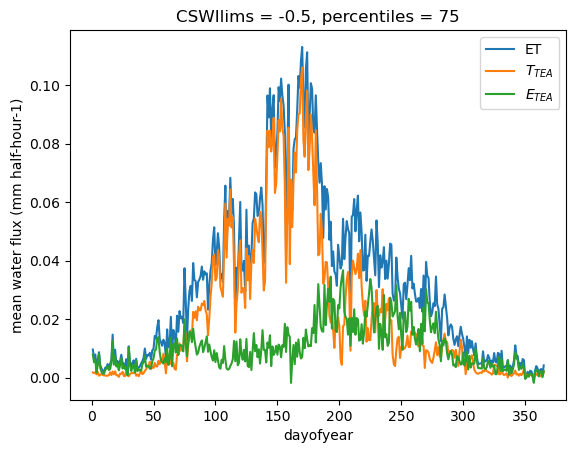

In [14]:
ds.ET.groupby('timestamp.dayofyear').mean().plot(label = 'ET')
ds.TEA_T.sel(percentiles=75).groupby('timestamp.dayofyear').mean().plot(label = r'$T_{TEA}$')
(ds.ET-ds.TEA_T.sel(percentiles=75)).groupby('timestamp.dayofyear').mean().plot(label = r'$E_{TEA}$')
pl.ylabel("mean water flux (mm half-hour-1)")
pl.legend()

Annual totals and T/ET ratio (only complete-data steps).

In [15]:
T75 = ds.TEA_T.sel(percentiles=75)
valid = np.isfinite(ds.ET) & np.isfinite(T75)
annual = pd.DataFrame({
    'ET_mm':  ds.ET.where(valid).groupby('timestamp.year').sum().to_series(),
    'T_mm':   T75.where(valid).groupby('timestamp.year').sum().to_series(),
})
annual['E_mm']  = annual.ET_mm - annual.T_mm
annual['T/ET']  = annual.T_mm / annual.ET_mm
annual.round(3)

,ET_mm,T_mm,E_mm,T/ET
year,,,,
2017,618.735,417.901,200.834,0.675
2018,534.317,354.396,179.921,0.663
2019,538.222,366.458,171.764,0.681


Diurnal cycle on a summer day (change the date as needed).

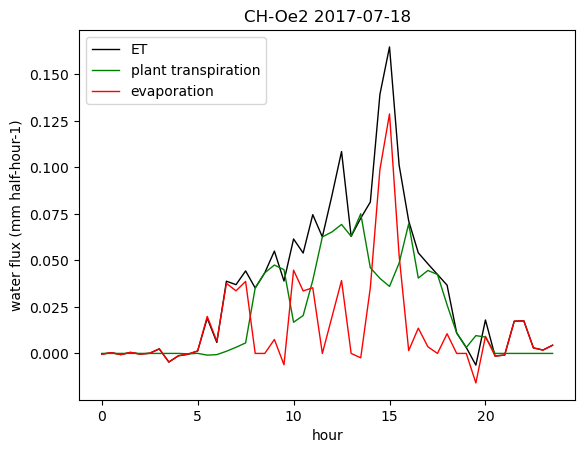

In [16]:
DAY = f'{START[:4]}-07-18'
hours = np.arange(0, 24, 24/nStepsPerDay)
pl.plot(hours, ds.ET.sel(timestamp=DAY), color='k', lw=1, label="ET")
pl.plot(hours, ds.TEA_T.sel(percentiles=75, timestamp=DAY), color='green', lw=1, label="plant transpiration")
pl.plot(hours, ds.TEA_E.sel(percentiles=75, timestamp=DAY), color='red', lw=1, label="evaporation")
pl.ylabel("water flux (mm half-hour-1)")
pl.xlabel("hour")
pl.title(f"{SITE} {DAY}")
pl.legend(loc='upper left')

### data output

Full TEA dataset as netcdf, plus the original data with the 75th-percentile T and E added (netcdf and csv).
All file names start with `CH-Oe2_` so nothing existing is overwritten.

In [17]:
tag = f"{SITE}_{START}-{END}"
ds.to_netcdf(f"{tag}_TEA_output.nc")

ec[f'TEA_T_{GPP_VAR[-2:]}_75'] = (('time'), ds.TEA_T.sel(percentiles=75).values)
ec[f'TEA_T_{GPP_VAR[-2:]}_75'] = ec[f'TEA_T_{GPP_VAR[-2:]}_75'].assign_attrs(
    long_name = f'transpiration from TEA using the 75th percentile, using {GPP_VAR}', units = 'mm per timestep')
ec[f'TEA_E_{GPP_VAR[-2:]}_75'] = (('time'), ds.TEA_E.sel(percentiles=75).values)
ec[f'TEA_E_{GPP_VAR[-2:]}_75'] = ec[f'TEA_E_{GPP_VAR[-2:]}_75'].assign_attrs(
    long_name = f'evaporation from TEA using the 75th percentile, using {GPP_VAR}', units = 'mm per timestep')

ec.to_netcdf(f"{tag}_with_TEA.nc")
ec.to_dataframe().to_csv(f"{tag}_with_TEA.csv")
print("written:", f"{tag}_TEA_output.nc", f"{tag}_with_TEA.nc", f"{tag}_with_TEA.csv")

written: CH-Oe2_2017-2019_TEA_output.nc CH-Oe2_2017-2019_with_TEA.nc CH-Oe2_2017-2019_with_TEA.csv
